# Ordenacao Completa em Java
## Merge Sort, Quick Sort, Limite Inferior e Counting Sort

**COMP0497 — Algoritmos e Estruturas de Dados I**  
Prof. Dr. Andre Yoshiaki Kashiwabara — DCOMP/UFS

---

Este tutorial cobre os principais algoritmos de ordenacao avancada, com implementacoes em Java e visualizacoes em Python.

## 1. Merge Sort

### 1.1 Motivacao

O Insertion Sort tem complexidade $\Theta(n^2)$ no pior caso. Podemos fazer melhor usando o paradigma **Divisao e Conquista**:

1. **Dividir**: partir o array ao meio
2. **Conquistar**: ordenar recursivamente cada metade
3. **Combinar**: intercalar (*merge*) as duas metades ordenadas

O Merge Sort alcanca $\Theta(n \log n)$ em **todos** os casos.

### 1.2 Implementacao em Java


> *Nota: Esta implementação segue o pseudocódigo do CLRS. A simulação Python abaixo reproduz a mesma lógica com rastreamento de passos passo a passo.*
```java
public class MergeSort {

    public static void mergeSort(int[] A, int p, int r) {
        if (p < r) {
            int q = (p + r) / 2;
            mergeSort(A, p, q);
            mergeSort(A, q + 1, r);
            merge(A, p, q, r);
        }
    }

    public static void merge(int[] A, int p, int q, int r) {
        int n1 = q - p + 1;
        int n2 = r - q;

        int[] L = new int[n1 + 1];
        int[] R = new int[n2 + 1];

        for (int i = 0; i < n1; i++) L[i] = A[p + i];
        for (int j = 0; j < n2; j++) R[j] = A[q + 1 + j];

        // AVISO: Integer.MAX_VALUE como sentinela falha se a entrada contiver Integer.MAX_VALUE.
        // Alternativa segura: use verificacao de limites (veja Exercicio 1).
        L[n1] = Integer.MAX_VALUE;  // sentinela
        R[n2] = Integer.MAX_VALUE;  // sentinela

        int i = 0, j = 0;
        for (int k = p; k <= r; k++) {
            if (L[i] <= R[j]) {
                A[k] = L[i];
                i++;
            } else {
                A[k] = R[j];
                j++;
            }
        }
    }

    public static void main(String[] args) {
        int[] A = {5, 2, 4, 6, 1, 3, 2, 6};
        mergeSort(A, 0, A.length - 1);
        System.out.println(java.util.Arrays.toString(A));
        // Saida: [1, 2, 2, 3, 4, 5, 6, 6]
    }
}
```

### 1.3 Simulacao Interativa (Python)

In [ ]:
def merge(A, p, q, r, log):
    L = A[p:q+1] + [float('inf')]
    R = A[q+1:r+1] + [float('inf')]
    i = j = 0
    for k in range(p, r + 1):
        if L[i] <= R[j]:
            A[k] = L[i]
            i += 1
        else:
            A[k] = R[j]
            j += 1
    log.append(('merge', p, r, A[:]))

def merge_sort(A, p, r, log):
    if p < r:
        q = (p + r) // 2
        log.append(('split', p, q, r, A[:]))
        merge_sort(A, p, q, log)
        merge_sort(A, q + 1, r, log)
        merge(A, p, q, r, log)

A = [5, 2, 4, 6, 1, 3, 2, 6]
log = []
merge_sort(A, 0, len(A) - 1, log)

print("=== Trace do Merge Sort ===")
for step in log:
    if step[0] == 'split':
        _, p, q, r, state = step
        print(f"  Dividir: A[{p}..{r}] -> A[{p}..{q}] + A[{q+1}..{r}]")
    else:
        _, p, r, state = step
        print(f"  Merge:   A[{p}..{r}] = {state[p:r+1]}")

print(f"\nResultado: {A}")

=== Trace do Merge Sort ===
  Dividir: A[0..7] -> A[0..3] + A[4..7]
  Dividir: A[0..3] -> A[0..1] + A[2..3]
  Dividir: A[0..1] -> A[0..0] + A[1..1]
  Merge:   A[0..1] = [2, 5]
  Dividir: A[2..3] -> A[2..2] + A[3..3]
  Merge:   A[2..3] = [4, 6]
  Merge:   A[0..3] = [2, 4, 5, 6]
  Dividir: A[4..7] -> A[4..5] + A[6..7]
  Dividir: A[4..5] -> A[4..4] + A[5..5]
  Merge:   A[4..5] = [1, 3]
  Dividir: A[6..7] -> A[6..6] + A[7..7]
  Merge:   A[6..7] = [2, 6]
  Merge:   A[4..7] = [1, 2, 3, 6]
  Merge:   A[0..7] = [1, 2, 2, 3, 4, 5, 6, 6]

Resultado: [1, 2, 2, 3, 4, 5, 6, 6]


### 1.4 Analise de Complexidade

**Recorrencia:**
$$T(n) = \begin{cases} \Theta(1) & \text{se } n = 1 \\ 2T(n/2) + \Theta(n) & \text{se } n > 1 \end{cases}$$

**Solucao** (Teorema Mestre, caso 2): $T(n) = \Theta(n \log n)$

| Caso | Complexidade |
|------|-------------|
| Melhor | $\Theta(n \log n)$ |
| Medio | $\Theta(n \log n)$ |
| Pior | $\Theta(n \log n)$ |

**Desvantagem:** Espaco auxiliar $\Theta(n)$ — nao e *in-place*.

---
## 2. Quick Sort

### 2.1 Ideia Central

O Quick Sort tambem usa Divisao e Conquista, mas "ao contrario":
1. **Escolher** um elemento *pivo* $x$
2. **Particionar**: rearranjar em $[\leq x] \mid [x] \mid [\geq x]$
3. **Conquistar**: ordenar recursivamente esquerda e direita
4. **Combinar**: nada a fazer!

- **In-place**: $O(\log n)$ de pilha
- Caso medio: $\Theta(n \log n)$
- Pior caso: $\Theta(n^2)$

### 2.2 Implementacao em Java (Particao de Lomuto)


> *Nota: Esta implementação segue o pseudocódigo do CLRS. A simulação Python abaixo reproduz a mesma lógica com rastreamento de passos passo a passo.*
```java
public class QuickSort {

    public static void quickSort(int[] A, int p, int r) {
        if (p < r) {
            int q = partition(A, p, r);
            quickSort(A, p, q - 1);
            quickSort(A, q + 1, r);
        }
    }

    // Particao de Lomuto: pivo = ultimo elemento
    public static int partition(int[] A, int p, int r) {
        int x = A[r];  // pivo
        int i = p - 1;
        for (int j = p; j < r; j++) {
            if (A[j] <= x) {
                i++;
                // trocar A[i] <-> A[j]
                int temp = A[i];
                A[i] = A[j];
                A[j] = temp;
            }
        }
        // colocar pivo na posicao correta
        int temp = A[i + 1];
        A[i + 1] = A[r];
        A[r] = temp;
        return i + 1;
    }

    public static void main(String[] args) {
        int[] A = {2, 8, 7, 1, 3, 5, 6, 4};
        quickSort(A, 0, A.length - 1);
        System.out.println(java.util.Arrays.toString(A));
        // Saida: [1, 2, 3, 4, 5, 6, 7, 8]
    }
}
```

**Invariante do loop (Partition):**
- $A[p..i] \leq x$ (elementos menores ou iguais ao pivo)
- $A[i{+}1..j{-}1] > x$ (elementos maiores que o pivo)
- $A[r] = x$ (pivo)

### 2.3 Simulacao Interativa

In [ ]:
def partition(A, p, r, log):
    x = A[r]  # pivo
    i = p - 1
    for j in range(p, r):
        if A[j] <= x:
            i += 1
            A[i], A[j] = A[j], A[i]
    A[i + 1], A[r] = A[r], A[i + 1]
    log.append(f"  Partition A[{p}..{r}]: pivo={x}, posicao final={i+1}, resultado={A[p:r+1]}")
    return i + 1

def quick_sort(A, p, r, log):
    if p < r:
        q = partition(A, p, r, log)
        quick_sort(A, p, q - 1, log)
        quick_sort(A, q + 1, r, log)

A = [2, 8, 7, 1, 3, 5, 6, 4]
print(f"Entrada: {A}")
log = []
quick_sort(A, 0, len(A) - 1, log)

print("\n=== Trace do Quick Sort ===")
for step in log:
    print(step)

print(f"\nResultado: {A}")

### 2.4 Quick Sort Randomizado (Java)

```java
import java.util.Random;

public class RandomizedQuickSort {
    static Random rand = new Random();

    public static int randomizedPartition(int[] A, int p, int r) {
        int i = p + rand.nextInt(r - p + 1);
        // trocar A[i] <-> A[r]
        int temp = A[i]; A[i] = A[r]; A[r] = temp;
        return partition(A, p, r);  // mesma partition de Lomuto
    }

    public static void randomizedQuickSort(int[] A, int p, int r) {
        if (p < r) {
            int q = randomizedPartition(A, p, r);
            randomizedQuickSort(A, p, q - 1);
            randomizedQuickSort(A, q + 1, r);
        }
    }
}
```

**Por que randomizar?**
- Elimina dependencia da entrada
- Pior caso ainda $\Theta(n^2)$, mas com probabilidade *exponencialmente pequena*
- Tempo esperado: $\Theta(n \log n)$ para **qualquer** entrada

### 2.5 Analise do Quick Sort

| Caso | Quando ocorre | Recorrencia | Complexidade |
|------|---------------|-------------|-------------|
| **Pior** | Entrada ja ordenada (pivo = menor/maior) | $T(n) = T(0) + T(n-1) + \Theta(n)$ | $\Theta(n^2)$ |
| **Melhor** | Particao sempre equilibrada ($n/2 \mid n/2$) | $T(n) = 2T(n/2) + \Theta(n)$ | $\Theta(n \log n)$ |
| **Medio** | Permutacoes igualmente provaveis | — | $\Theta(n \log n)$ |

> **Nota:** Com o Quick Sort randomizado (§2.4), o pior caso deixa de estar associado a entradas específicas (como arrays ja ordenados) e ocorre com probabilidade exponencialmente pequena para qualquer entrada fixa.

### 2.6 Comparacao: Merge Sort vs Quick Sort

In [ ]:
import time
import random
import sys

# Python tem limite padrao de ~1000 chamadas recursivas.
# Aumentamos o limite para suportar arrays de ate ~10.000 elementos
# sem RecursionError. Em producao, prefira versoes iterativas.
sys.setrecursionlimit(20000)

# Versao funcional (nao in-place, cria novas listas) para benchmark de tempo.
# Veja a celula de simulacao acima para a versao com rastreamento de passos.
def merge_sort_py(A):
    if len(A) <= 1:
        return A
    mid = len(A) // 2
    L = merge_sort_py(A[:mid])
    R = merge_sort_py(A[mid:])
    result = []
    i = j = 0
    while i < len(L) and j < len(R):
        if L[i] <= R[j]:
            result.append(L[i]); i += 1
        else:
            result.append(R[j]); j += 1
    result.extend(L[i:])
    result.extend(R[j:])
    return result

def quick_sort_py(A):
    if len(A) <= 1:
        return A
    pivot = A[random.randint(0, len(A) - 1)]
    lo = [x for x in A if x < pivot]
    eq = [x for x in A if x == pivot]
    hi = [x for x in A if x > pivot]
    return quick_sort_py(lo) + eq + quick_sort_py(hi)

print(f"{'n':>8} | {'Merge Sort':>12} | {'Quick Sort':>12}")
print("-" * 40)
for n in [100, 500, 1000, 5000, 10000]:
    data = [random.randint(0, 10*n) for _ in range(n)]

    t0 = time.perf_counter()
    merge_sort_py(data[:])
    t_merge = time.perf_counter() - t0

    t0 = time.perf_counter()
    quick_sort_py(data[:])
    t_quick = time.perf_counter() - t0

    print(f"{n:>8} | {t_merge:>10.4f} s | {t_quick:>10.4f} s")

       n |   Merge Sort |   Quick Sort
----------------------------------------
     100 |     0.0002 s |     0.0002 s
     500 |     0.0009 s |     0.0010 s
    1000 |     0.0018 s |     0.0019 s
    5000 |     0.0111 s |     0.0093 s
   10000 |     0.0189 s |     0.0190 s


| Propriedade | Merge Sort | Quick Sort |
|---|---|---|
| Pior caso | $\Theta(n \log n)$ | $\Theta(n^2)$ |
| Caso medio | $\Theta(n \log n)$ | $\Theta(n \log n)$ |
| In-place | Nao | Sim |
| Estavel | Sim | Nao |
| Memoria extra | $\Theta(n)$ | $O(\log n)$ |

### 2.7 Demonstracao de Instabilidade do Quick Sort

O Quick Sort **nao e estavel**: elementos com chaves iguais podem trocar sua ordem relativa. O exemplo abaixo usa pares `(valor, rotulo)` para tornar isso visivel.

In [ ]:
# Demonstracao: Quick Sort nao e estavel
# Usamos pares (valor, rotulo) para rastrear a ordem relativa original.

def quick_sort_pares(A, p, r):
    if p < r:
        x_val = A[r][0]  # pivo pelo valor
        i = p - 1
        for j in range(p, r):
            if A[j][0] <= x_val:
                i += 1
                A[i], A[j] = A[j], A[i]
        A[i + 1], A[r] = A[r], A[i + 1]
        q = i + 1
        quick_sort_pares(A, p, q - 1)
        quick_sort_pares(A, q + 1, r)

# Entrada: dois elementos com chave 2 (rotulos 'a' e 'b' marcam a ordem original)
entrada = [(2, 'a'), (5, 'x'), (2, 'b'), (1, 'y'), (2, 'c')]
print(f"Entrada  : {entrada}")
print(f"Ordem relativa dos elementos com chave 2: a, b, c  (esperado se estavel)")

import copy
A = copy.deepcopy(entrada)
quick_sort_pares(A, 0, len(A) - 1)
print(f"\nSaida QS : {A}")

chave2 = [r for v, r in A if v == 2]
print(f"Ordem relativa dos '2' apos QS: {chave2}")
print(f"Instavel? {'SIM' if chave2 != ['a','b','c'] else 'NAO (coincidencia de particao)'}")
print("\n[Se a ordem mudou, o Quick Sort e instavel. Este resultado e deterministico para o Quick Sort de Lomuto com pivo fixo. Com o Quick Sort randomizado (§2.4), o resultado pode variar entre execucoes.]")

Entrada  : [(2, 'a'), (5, 'x'), (2, 'b'), (1, 'y'), (2, 'c')]
Ordem relativa dos elementos com chave 2: a, b, c  (esperado se estavel)

Saida QS : [(1, 'y'), (2, 'b'), (2, 'a'), (2, 'c'), (5, 'x')]
Ordem relativa dos '2' apos QS: ['b', 'a', 'c']
Instavel? SIM

[Se a ordem mudou, o Quick Sort e instavel. Este resultado e deterministico para o Quick Sort de Lomuto com pivo fixo. Com o Quick Sort randomizado (§2.4), o resultado pode variar entre execucoes.]


---
## 3. Limite Inferior para Ordenacao por Comparacao

### 3.1 Arvore de Decisao

Qualquer algoritmo de ordenacao por comparacao pode ser modelado por uma **arvore de decisao** porque cada passo decide $a_i \leq a_j$ ou nao, determinando o proximo ramo — e assim qualquer execucao corresponde a um caminho raiz-folha na arvore:

- Cada **no interno** = uma comparacao $a_i : a_j$
- Cada **folha** = uma permutacao final
- **Profundidade** de uma folha = numero de comparacoes naquele caminho
- **Pior caso** = **altura** da arvore

### 3.2 O Argumento

1. A arvore deve ter $\geq n!$ folhas (para cobrir todas as permutacoes)
2. Uma arvore binaria de altura $h$ tem no maximo $2^h$ folhas
3. Logo: $2^h \geq n! \implies h \geq \log_2(n!)$
4. Pela aproximacao de Stirling: $\log_2(n!) = \Theta(n \log n)$
   *(Esboço: $n! \geq (n/e)^n \Rightarrow \log_2(n!) \geq n\log_2 n - n\log_2 e = \Omega(n \log n)$; o limite superior e simetrico.)*

### 3.3 Teorema

> **Qualquer algoritmo de ordenacao por comparacao requer $\Omega(n \log n)$ comparacoes no pior caso.**

Portanto, Merge Sort (e outros algoritmos com $\Theta(n \log n)$ no pior caso, como o Heap Sort abordado em COMP0498) sao **otimos assintoticamente**.

In [ ]:
import math

print("Limite inferior: log2(n!) comparacoes no pior caso")
print(f"{'n':>6} | {'n!':>15} | {'log2(n!)':>10} | {'n*log2(n)':>10}")
print("-" * 50)
for n in [3, 4, 5, 8, 16, 32, 64]:
    fatorial = math.factorial(n)
    log_fat = math.log2(fatorial)
    n_logn = n * math.log2(n)
    print(f"{n:>6} | {fatorial:>15} | {log_fat:>10.1f} | {n_logn:>10.1f}")

Limite inferior: log2(n!) comparacoes no pior caso
     n |              n! |   log2(n!) |  n*log2(n)
--------------------------------------------------
     3 |               6 |        2.6 |        4.8
     4 |              24 |        4.6 |        8.0
     5 |             120 |        6.9 |       11.6
     8 |           40320 |       15.3 |       24.0
    16 |  20922789888000 |       44.3 |       64.0
    32 | 263130836933693530167218012160000000 |      117.7 |      160.0
    64 | 126886932185884164103433389335161480802865516174545192198801894375214704230400000000000000 |      296.0 |      384.0


---
## 4. Counting Sort

### 4.1 Motivacao

O limite $\Omega(n \log n)$ vale apenas para algoritmos **baseados em comparacao**. Se sabemos mais sobre os dados (ex: inteiros em $[0, k]$), podemos ordenar em tempo **linear**!

### 4.2 Ideia

1. **Contar** quantas vezes cada valor aparece
2. **Acumular** prefixos para saber a posicao final de cada valor
3. **Espalhar** os elementos na posicao correta

**Complexidade:** $\Theta(n + k)$ — linear quando $k = O(n)$

### 4.3 Implementacao em Java


> *Nota: Esta implementação segue o pseudocódigo do CLRS. A simulação Python abaixo reproduz a mesma lógica com rastreamento de passos passo a passo.*
```java
public class CountingSort {

    // Precondition: todos os valores de A devem estar em [0, k].
    // Comportamento indefinido (ArrayIndexOutOfBoundsException) se A[j] < 0 ou A[j] > k.
    // A[0..n-1] com valores em [0, k]
    // B[0..n-1] = saida ordenada
    public static void countingSort(int[] A, int[] B, int k) {
        int n = A.length;
        int[] C = new int[k + 1];

        // Passo 1: contar ocorrencias
        for (int j = 0; j < n; j++) {
            C[A[j]]++;
        }

        // Passo 2: acumular prefixo
        for (int i = 1; i <= k; i++) {
            C[i] += C[i - 1];
        }

        // Passo 3: espalhar (de tras para frente = estavel)
        for (int j = n - 1; j >= 0; j--) {
            B[C[A[j]] - 1] = A[j];
            C[A[j]]--;
        }
    }

    public static void main(String[] args) {
        int[] A = {2, 5, 3, 0, 2, 3, 0, 3};
        int[] B = new int[A.length];
        countingSort(A, B, 5);
        System.out.println(java.util.Arrays.toString(B));
        // Saida: [0, 0, 2, 2, 3, 3, 3, 5]
    }
}
```

### 4.4 Simulacao Passo a Passo

In [ ]:
def counting_sort_verbose(A, k):
    n = len(A)
    C = [0] * (k + 1)
    B = [None] * n

    assert all(0 <= x <= k for x in A), f"Precondition violated: todos os valores devem estar em [0, {k}]"
    print(f"Entrada A = {A},  k = {k}")

    # Passo 1: contar
    for j in range(n):
        C[A[j]] += 1
    print(f"\nPasso 1 - Contagem:  C = {C}")
    print(f"  Interpretacao: valor 0 aparece {C[0]}x, valor 1 aparece {C[1]}x, ...")

    # Passo 2: acumular
    for i in range(1, k + 1):
        C[i] += C[i - 1]
    print(f"\nPasso 2 - Prefixo acumulado: C = {C}")
    print(f"  C[i] = numero de elementos <= i")

    # Passo 3: espalhar
    print(f"\nPasso 3 - Espalhamento (de tras para frente):")
    for j in range(n - 1, -1, -1):
        pos = C[A[j]] - 1
        B[pos] = A[j]
        C[A[j]] -= 1
        print(f"  A[{j}]={A[j]} -> B[{pos}]   B={B}")

    print(f"\nResultado: B = {B}")
    return B

A = [2, 5, 3, 0, 2, 3, 0, 3]
counting_sort_verbose(A, 5)

Entrada A = [2, 5, 3, 0, 2, 3, 0, 3],  k = 5

Passo 1 - Contagem:  C = [2, 0, 2, 3, 0, 1]
  Interpretacao: valor 0 aparece 2x, valor 1 aparece 0x, ...

Passo 2 - Prefixo acumulado: C = [2, 2, 4, 7, 7, 8]
  C[i] = numero de elementos <= i

Passo 3 - Espalhamento (de tras para frente):
  A[7]=3 -> B[6]   B=[None, None, None, None, None, None, 3, None]
  A[6]=0 -> B[1]   B=[None, 0, None, None, None, None, 3, None]
  A[5]=3 -> B[5]   B=[None, 0, None, None, None, 3, 3, None]
  A[4]=2 -> B[3]   B=[None, 0, None, 2, None, 3, 3, None]
  A[3]=0 -> B[0]   B=[0, 0, None, 2, None, 3, 3, None]
  A[2]=3 -> B[4]   B=[0, 0, None, 2, 3, 3, 3, None]
  A[1]=5 -> B[7]   B=[0, 0, None, 2, 3, 3, 3, 5]
  A[0]=2 -> B[2]   B=[0, 0, 2, 2, 3, 3, 3, 5]

Resultado: B = [0, 0, 2, 2, 3, 3, 3, 5]


[0, 0, 2, 2, 3, 3, 3, 5]

### 4.5 Estabilidade

O Counting Sort e **estavel**: elementos com chaves iguais aparecem na saida na mesma ordem relativa da entrada.

Isso acontece porque o 3o loop percorre $A$ **de tras para frente**, e $C[v]$ fornece a posicao do *ultimo* elemento nao colocado com chave $v$.

**Importancia:** A estabilidade torna o Counting Sort util como sub-rotina do **Radix Sort**.

### 4.6 Complexidade

| Etapa | Custo |
|-------|-------|
| Inicializar $C$ | $\Theta(k)$ |
| Contar (1o for) | $\Theta(n)$ |
| Acumular (2o for) | $\Theta(k)$ |
| Espalhar (3o for) | $\Theta(n)$ |
| **Total** | $\Theta(n + k)$ |

- Se $k = O(n)$: tempo **linear** $\Theta(n)$
- Nao usa comparacoes $\Rightarrow$ nao viola o limite $\Omega(n \log n)$

---
## 5. Visualizacao Comparativa

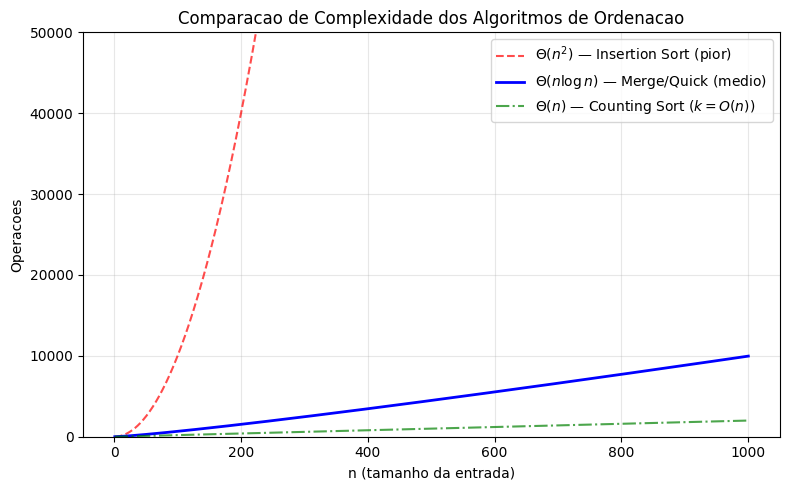

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = np.arange(1, 1001)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(n, n**2, 'r--', label=r'$\Theta(n^2)$ — Insertion Sort (pior)', alpha=0.7)
ax.plot(n, n * np.log2(n + 1), 'b-', label=r'$\Theta(n \log n)$ — Merge/Quick (medio)', linewidth=2)
ax.plot(n, 2 * n, 'g-.', label=r'$\Theta(n)$ — Counting Sort ($k=O(n)$)', alpha=0.7)
ax.set_xlabel('n (tamanho da entrada)')
ax.set_ylabel('Operacoes')
ax.set_title('Comparacao de Complexidade dos Algoritmos de Ordenacao')
ax.legend()
ax.set_ylim(0, 50000)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# Execute a partir do diretorio notebooks/ ou ajuste o caminho abaixo.
plt.show()  # interativo; a figura tambem foi salva em Figures/ para uso em slides

---
## 6. Resumo Geral

| Algoritmo | Pior Caso | Caso Medio | Espaco | Estavel? |
|---|---|---|---|---|
| Insertion Sort | $\Theta(n^2)$ | $\Theta(n^2)$ | $O(1)$ | Sim |
| Merge Sort | $\Theta(n \log n)$ | $\Theta(n \log n)$ | $\Theta(n)$ | Sim |
| Quick Sort | $\Theta(n^2)$ | $\Theta(n \log n)$ | $O(\log n)$ | Nao |
| **Counting Sort** | $\Theta(n+k)$ | $\Theta(n+k)$ | $O(n+k)$ | **Sim** |

**Pontos-chave:**
- $\Omega(n \log n)$ e o limite inferior para ordenacao por comparacao
- Counting Sort quebra essa barreira explorando propriedades dos dados
- Quick Sort e o mais rapido na pratica (apesar do pior caso $n^2$)
- Merge Sort garante $n \log n$ mas precisa de memoria extra

### Referencias
- Cormen, Leiserson, Rivest, Stein. *Introduction to Algorithms*, 4a ed., MIT Press, 2022.
- Sedgewick, Wayne. *Algorithms*, 4a ed., Addison-Wesley, 2011.

---
## 7. Exercicios

1. Implemente o Merge Sort em Java sem usar sentinela ($\infty$). Use verificacao de limites.

R = public class MergeSort {

    public static void mergeSort(int[] array, int inicio, int fim) {
        if (inicio < fim)
        {
            int meio = inicio + (fim - inicio) / 2;

            mergeSort(array, inicio, meio);
            mergeSort(array, meio + 1, fim);

            merge(array, inicio, meio, fim);
        }
    }

    private static void merge(int[] array, int inicio, int meio, int fim)
    {
        int n1 = meio - inicio + 1;
        int n2 = fim - meio;

        int[] esquerdo = new int[n1];
        int[] direito = new int[n2];

        for (int i = 0; i < n1; i++) esquerdo[i] = array[inicio + i];
        for (int j = 0; j < n2; j++) direito[j] = array[meio + 1 + j];

        int i = 0, j = 0;
        int k = inicio;

        while (i < n1 && j < n2)
        {
            if (esquerdo[i] <= direito[j]) {
                array[k] = esquerdo[i];
                i++;
            } else {
                array[k] = direito[j];
                j++;
            }
            k++;
        }

        while (i < n1)
        {
            array[k] = esquerdo[i];
            i++;
            k++;
        }

        while (j < n2)
        {
            array[k] = direito[j];
            j++;
            k++;
        }
    }
}

2. Modifique a `partition` para usar a **mediana de 3** como pivo.

R = public class QuickSortMediana3 {

    public static void quickSort(int[] array, int inicio, int fim)
    {
        if (inicio < fim)
        {
            int indicePivo = partition(array, inicio, fim);
            quickSort(array, inicio, indicePivo - 1);
            quickSort(array, indicePivo + 1, fim);
        }
    }

    private static int partition(int[] array, int inicio, int fim)
    {
        colocaMedianaNoFim(array, inicio, fim);
        
        int pivo = array[fim];
        int i = inicio - 1;

        for (int j = inicio; j < fim; j++)
        {
            if (array[j] <= pivo)
            {
                i++;
                swap(array, i, j);
            }
        }
        
        swap(array, i + 1, fim);
        return i + 1;
    }

    private static void colocaMedianaNoFim(int[] array, int inicio, int fim)
    {
        int meio = inicio + (fim - inicio) / 2;

        if (array[inicio] > array[meio])
        {
            swap(array, inicio, meio);
        }
        if (array[inicio] > array[fim])
        {
            swap(array, inicio, fim);
        }
        if (array[meio] > array[fim])
        {
            swap(array, meio, fim);
        }

        swap(array, meio, fim);
    }

    private static void swap(int[] array, int i, int j)
    {
        int temp = array[i];
        array[i] = array[j];
        array[j] = temp;
    }
}

3. Qual e a complexidade do Counting Sort quando $k = n^2$? Vale a pena usar?

R = O(n^2). Não vale a pena, pelo desperdício da memória e da inversão da vantagem.

4. Mostre que o Counting Sort e estavel. O que acontece se o 3o loop percorrer de frente para tras?
   *(Dica: use um array onde dois elementos distintos tenham a mesma chave — ex: pares `(valor, indice_original)` como `[(2,'a'), (5,'b'), (2,'c')]`. Com chaves todas distintas, a instabilidade nao e observavel.)*

R = O Counting Sort é estável porque seu terceiro loop percorre o array original de trás para frente. Usando o exemplo [(2,'a'), (5,'b'), (2,'c')], o array de frequências reserva os índices 0 e 1 para a chave 2. Ao varrer de trás para frente, o elemento (2,'c') é processado primeiro e alocado na última posição disponível (índice 1), enquanto (2,'a') é processado depois e colocado no índice 0, preservando a ordem original entre eles.

Se o loop for invertido para percorrer de frente para trás, o algoritmo torna-se instável. Nesse cenário, o primeiro elemento encontrado, (2,'a'), seria colocado na última posição reservada (índice 1), e o elemento posterior, (2,'c'), ocuparia o índice 0. Isso resultaria na inversão da ordem original dos elementos idênticos no array final.


5. Dados 1 milhao de notas de alunos (0 a 100), qual algoritmo voce usaria? Justifique.

R = O algoritmo ideal é o Counting Sort. Como o volume de dados é enorme e o intervalo de notas é minúsculo e fixo, o algoritmo opera em tempo linear.